# Primeira Chamada | A trilha da acadêmica: A.7. Otimizadores 

**Disciplina:** Redes Neurais e Algoritimos Genéticos

**Autora:** Giulia Sales Ferreira            -              **Turma:** 2025


## Otimizadores para redes neurais: Implementação em python puro 

### Conceitos Fundamentais 

#### O que é um Otimizador?

Um otimizador é o algoritmo responsável por atualizar os pesos e vieses de uma rede neural durante o treinamento. Ele determina como o modelo aprende a partir dos dados de entrada. A fórmula matemática básica de atualização é:


$ w_{\text{novo}} = w_{\text{antigo}} - \alpha \cdot \nabla L $

onde $ w $ representa os pesos, $ \alpha $ é a taxa de aprendizado e $ \nabla L $ é o gradiente da função de perda. Cada otimizador implementa uma variação desta fórmula básica para melhorar três aspectos principais: a velocidade de convergência, permitindo que o modelo aprenda mais rapidamente; a estabilidade do treinamento, evitando oscilações excessivas; e a qualidade da solução final, chegando a um mínimo global mais eficiente.

#### O que são Gradientes?


Gradientes são as derivadas parciais da função de perda em relação a cada parâmetro da rede. Eles funcionam como uma bússola que indica tanto a direção quanto a magnitude do ajuste necessário. Quando o gradiente é positivo, o parâmetro deve ser diminuído; quando negativo, deve ser aumentado. Gradientes com maior magnitude indicam a necessidade de ajustes mais significativos, enquanto gradientes pequenos sugerem ajustes sutis.

#### Taxa de Aprendizado (Learning Rate)

A taxa de aprendizado controla o tamanho do passo dado na direção oposta ao gradiente. Uma taxa alta acelera o aprendizado, mas pode causar oscilações e impedir a convergência. Por outro lado, uma taxa baixa garante maior estabilidade, embora torne o processo mais lento. Encontrar a taxa ideal representa um dos maiores desafios no treinamento de redes neurais.

### Os Otimizadores que Implementaremos

Vamos implementar três otimizadores fundamentais, cada um com características específicas:

1. **SGD (Stochastic Gradient Descent)**: O mais simples, atualiza os pesos usando apenas o gradiente atual.
2. **AdaGrad (Adaptive Gradient)**: Ajusta individualmente a taxa de aprendizado para cada parâmetro com base no histórico de gradientes.
3. **Adam (Adaptive Moment Estimation)**: Combina as melhores características do Momentum e RMSProp, sendo atualmente o mais utilizado na prática.

Além disso, explicaremos brevemente outros dois otimizadores:
1. **SGD com Momentum**: Adiciona inércia ao processo, suavizando oscilações e acelerando a convergência em vales estreitos.
2. **RMSProp (Root Mean Square Propagation)**: Melhora o AdaGrad utilizando uma média móvel exponencial dos quadrados dos gradientes.

### O Problema: Diagnóstico de Câncer de Mama

Utilizaremos o dataset Breast Cancer Wisconsin, que contém 569 amostras com 30 características extraídas de imagens de biopsia de tecido mamário. O objetivo é classificar tumores como **benignos (0)** ou **malignos (1)**. 

As características incluem medidas morfológicas dos núcleos celulares, como raio médio, textura média, perímetro médio, área média, suavidade média, compacidade média, concavidade média, pontos côncavos médios, simetria média e dimensão fractal média. Essas features capturam propriedades geométricas e texturais essenciais para o diagnóstico.

### obs. Por que Python Puro?

Implementar otimizadores em Python puro trouxe vantagens fundamentais para o aprendizado profundo: como a compreensão matemática de cada algoritmo sem abstrações de bibliotecas; deleção da "caixa preta" presente em frameworks como TensorFlow ou PyTorch; oportunidade de grande controle sobre hiperparâmetros; e uma base para desenvolver otimizadores customizados.

## Importação das bibliotecas e configurações

In [1]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from collections import Counter

# Configuracoes de reprodutibilidade 
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Configuracoes de visualizacao
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

## O Dataset: Breast Cancer Wisconsin

### Sobre o Dataset:

O Dataset contem 569 amostras (pacientes), cada uma com 30 características extraídas de imagens de biopsia. As caracteristicas são:

    - radius: raio do nucleo
    - texture: textura (desvio padrao dos tons de cinza)
    - perimeter: perimetro
    - area: área
    - smoothness: suavidade (variação local do raio)
    - compactness: compacidade (perimetro^2 / area - 1.0)
    - concavity: concavidade (gravidade das porcoes concavas)
    - concave_points: número de porções côncavas
    - symmetry: simetria
    - fractal_dimension: dimensão fractal (aproximação da costa)

Para cada característica, temos três medidas: mean (média), se (erro padrão), e worst (pior caso). 
Total: 30 features.

**Variável alvo:**

    - 0: tumor benigno (nao cancerigeno)
    - 1: tumor maligno (cancerigeno)

In [2]:
# Carregar o dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# Criar DataFrame para visualizacao
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['target_name'] = df['target'].map({0: 'benigno', 1: 'maligno'})

print("DATASET BREAST CANCER WISCONSIN")
print()

print(f"\nNumero de amostras: {len(df)}")
print(f"Numero de caracteristicas: {len(feature_names)}")
print(f"\nDistribuicao das classes:")
print(f"  Benigno (0): {sum(y == 0)} amostras ({sum(y == 0)/len(y)*100:.1f}%)")
print(f"  Maligno (1): {sum(y == 1)} amostras ({sum(y == 1)/len(y)*100:.1f}%)")

print(f"\nPrimeiras 5 amostras:")
print(df.head())

print(f"\nEstatisticas descritivas das caracteristicas:")
print(df[feature_names[:5]].describe())

DATASET BREAST CANCER WISCONSIN


Numero de amostras: 569
Numero de caracteristicas: 30

Distribuicao das classes:
  Benigno (0): 212 amostras (37.3%)
  Maligno (1): 357 amostras (62.7%)

Primeiras 5 amostras:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.24

### Análise de Correlação

A matriz de correlação revela como as características se relacionam entre si. Cores vermelhas intensas indicam correlação positiva forte (> 0.8), enquanto azuis escuras mostram correlação negativa. No dataset de câncer de mama, medidas geométricas como radius, perimeter e area apresentam alta correlação esperada.

### Distribuição por Classe

Histogramas e boxplots mostram a separação natural entre tumores benignos (verde) e malignos (vermelho). Características com pouca sobreposição entre as distribuições são preditoras poderosas para classificação.

### Visualizando os dados:

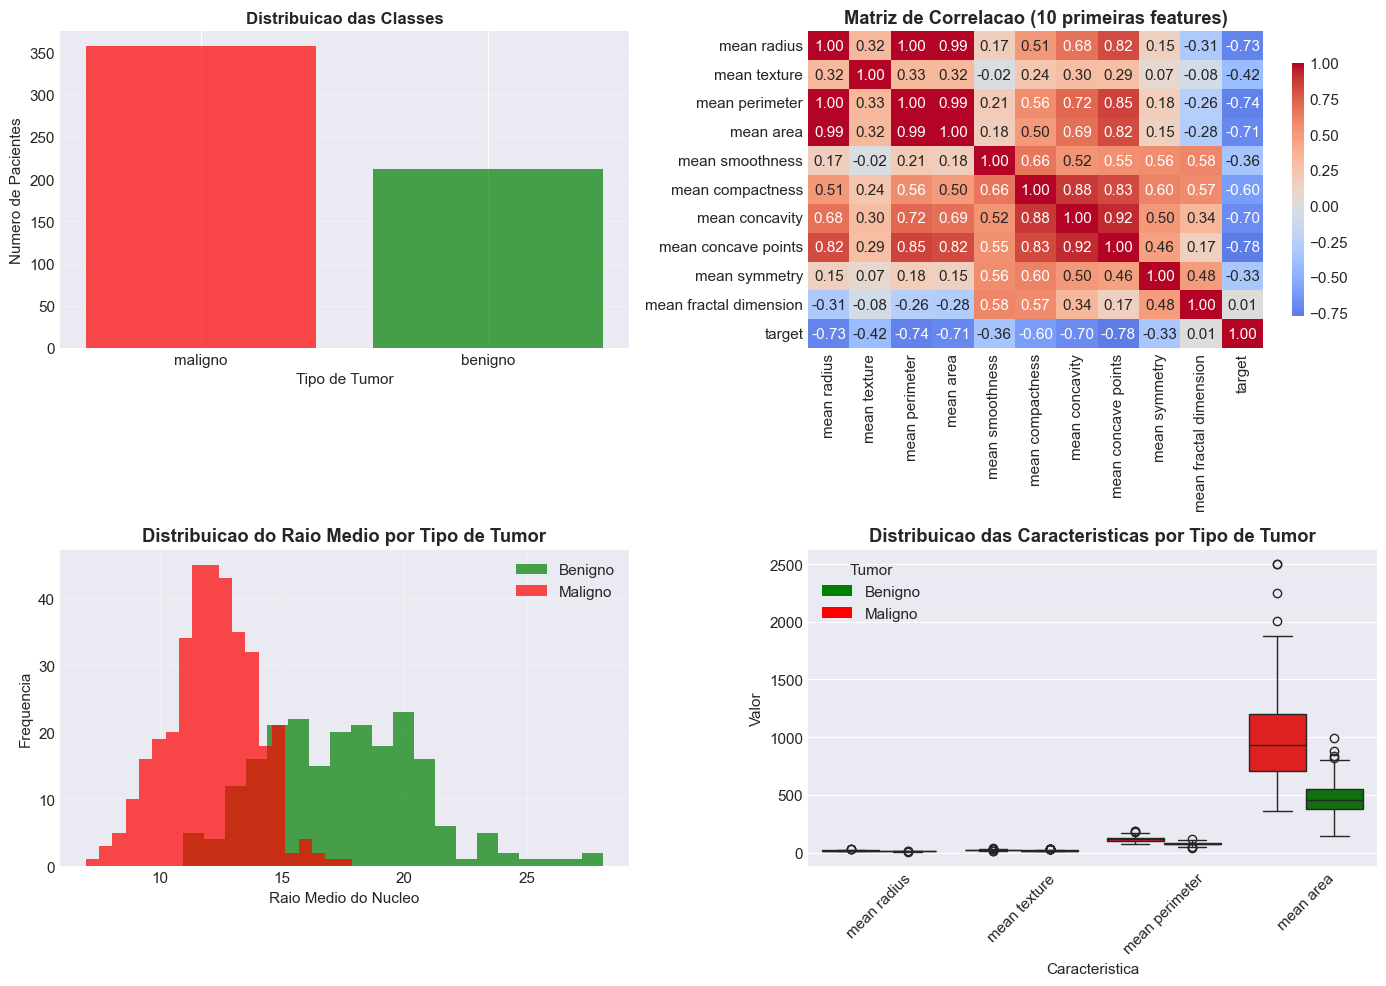

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# cores padrao
cor_benigno = 'green'
cor_maligno = 'red'

# 1. Distribuicao das classes
ax1 = axes[0, 0]

contagem = df['target_name'].value_counts()

# garantir ordem consistente (maligno, benigno)
ordem = ['maligno', 'benigno']
contagem = contagem.reindex(ordem)

ax1.bar(contagem.index, contagem.values,
        color=[cor_maligno, cor_benigno], alpha=0.7)

ax1.set_title('Distribuicao das Classes', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tipo de Tumor')
ax1.set_ylabel('Numero de Pacientes')
ax1.grid(axis='y', alpha=0.3)

# 2. Matriz de correlacao
ax2 = axes[0, 1]
corr_matrix = df[list(feature_names[:10]) + ['target']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            center=0, ax=ax2, fmt='.2f',
            cbar_kws={'shrink': 0.8})

ax2.set_title('Matriz de Correlacao (10 primeiras features)', fontweight='bold')

# 3. Distribuicao de uma caracteristica por classe
ax3 = axes[1, 0]

benigno = df[df['target'] == 0]['mean radius']
maligno = df[df['target'] == 1]['mean radius']

ax3.hist(benigno, bins=20, alpha=0.7,
         label='Benigno', color=cor_benigno)

ax3.hist(maligno, bins=20, alpha=0.7,
         label='Maligno', color=cor_maligno)

ax3.set_xlabel('Raio Medio do Nucleo')
ax3.set_ylabel('Frequencia')
ax3.set_title('Distribuicao do Raio Medio por Tipo de Tumor', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Boxplot comparativo
ax4 = axes[1, 1]

features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

df_melt = df.melt(id_vars=['target'],
                  value_vars=features_to_plot,
                  var_name='feature',
                  value_name='valor')

sns.boxplot(x='feature', y='valor',
            hue='target',
            data=df_melt,
            palette={0: cor_maligno, 1: cor_benigno},
            ax=ax4)

ax4.set_title('Distribuicao das Caracteristicas por Tipo de Tumor', fontweight='bold')
ax4.set_xlabel('Caracteristica')
ax4.set_ylabel('Valor')
legend_elements = [Patch(facecolor=cor_benigno, label='Benigno'),
                   Patch(facecolor=cor_maligno, label='Maligno')]
ax4.legend(handles=legend_elements, title='Tumor')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### O que pode ser observado? 

- Tumores malignos apresentam núcleos maiores (mean_radius: ~17 vs ~12 para benignos)

- Alta correlação entre radius, perimeter e area (> 0.95), como esperado geometricamente

- Maior variabilidade nos tumores malignos (boxplots com whiskers mais longos)

- Distribuição balanceada: 63% maligno, 37% benigno - ideal para comparar otimizadores

   - Implicação para otimizadores: Features com boa separação + correlações estáveis = gradientes informativos e estáveis para os métodos.

## Divisão dos dados: Treino, Validação e Teste

### Por que dividir os dados?

A divisão dos dados é um conceito fundamental em Machine Learning que permite avaliar se o modelo aprendeu padrões gerais ou apenas decorou os dados de treinamento. Sem essa separação, não conseguimos medir a capacidade de generalização do modelo para novos pacientes.

| Conjunto  | Proporção | Função Principal                                               |
| --------- | --------- | -------------------------------------------------------------- |
| Treino    | 60%       | O modelo ajusta pesos e vieses                                 |
| Validação | 20%       | Monitora overfitting durante o treino e ajusta hiperparâmetros |
| Teste     | 20%       | Avaliação final da generalização (usado apenas uma vez)        |

### Overfitting vs. Underfitting

- UNDERFITTING: modelo nao aprendeu os padrões (erro alto no treino e no teste)
- OVERFITTING: modelo decorou os dados (erro baixo no treino, alto no teste)
- IDEAL: erro baixo no treino e no teste (modelo generaliza bem)

A validação é crucial para detectar overfitting precoce e escolher o melhor momento de parada do treinamento.

### Por que Normalizar os Dados?

Redes neurais são extremamente sensíveis às escalas das features. Características como `mean_area` (~ 600) dominariam `mean_texture` (~ 20) sem normalização, distorcendo os gradientes.

Fórmula da padronização z-score:

$ x_{\text{normalizado}} = \frac{x - \mu_{\text{treino}}}{\sigma_{\text{treino}}} $

obs. Média ($\mu$) e desvio padrão ($\sigma$) são calculados apenas nos dados de treino e aplicados a validação/teste. Isso previne data leakage (vazamento de informação).

### Preparando os dados:

In [4]:
# Separar features (X) e target (y)
X = df[feature_names].values
y = df['target'].values

print("PREPARANDO OS DADOS")
print()
print(f"Shape original - X: {X.shape} | y: {y.shape}")
print()

# Divisão estratificada (mantém proporção 63/37 das classes)
# Passo 1: Treino 60% vs Resto 40%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=0.6, random_state=SEED, stratify=y
)

# Passo 2: Resto 40% -> Validação 20% + Teste 20%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, train_size=0.5, random_state=SEED, stratify=y_temp
)

# Normalização Z-score (media=0, desvio=1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)     # fit APENAS no treino
X_val   = scaler.transform(X_val)           # mesma transformação
X_test  = scaler.transform(X_test)          # mesma transformação

print("Distribuição Final dos Dados:")
print(f"  Treino ({len(X_train)/len(X)*100:.1f}%):     {len(X_train)} amostras")
print(f"    Benigno: {sum(y_train == 0):3d} | Maligno: {sum(y_train == 1):3d}")
print(f"  Validação ({len(X_val)/len(X)*100:.1f}%):   {len(X_val)} amostras") 
print(f"    Benigno: {sum(y_val == 0):3d} | Maligno: {sum(y_val == 1):3d}")
print(f"  Teste ({len(X_test)/len(X)*100:.1f}%):      {len(X_test)} amostras")
print(f"    Benigno: {sum(y_test == 0):3d} | Maligno: {sum(y_test == 1):3d}")
print()

print("Verificação da Normalização:")
print(f"  Treino   - Média: {X_train.mean():7.3f} | Desvio: {X_train.std():.3f}")
print(f"  Validação- Média: {X_val.mean():7.3f}   | Desvio: {X_val.std():.3f}")
print(f"  Teste    - Média: {X_test.mean():7.3f}   | Desvio: {X_test.std():.3f}")

PREPARANDO OS DADOS

Shape original - X: (569, 30) | y: (569,)

Distribuição Final dos Dados:
  Treino (59.9%):     341 amostras
    Benigno: 127 | Maligno: 214
  Validação (20.0%):   114 amostras
    Benigno:  42 | Maligno:  72
  Teste (20.0%):      114 amostras
    Benigno:  43 | Maligno:  71

Verificação da Normalização:
  Treino   - Média:  -0.000 | Desvio: 1.000
  Validação- Média:   0.003   | Desvio: 0.884
  Teste    - Média:   0.055   | Desvio: 1.153


## Implementação da Rede Neural em Python puro

### Arquitetura da rede

A rede neural multicamada possuirá três camadas principais: entrada, uma camada escondida e saída. 

A camada de entrada tem 30 neurônios, um para cada característica do dataset de câncer de mama. A camada escondida contém 16 neurônios que aprendem combinações não-lineares das características de entrada. 

Finalmente, a camada de saída tem um único neurônio que produz a probabilidade de o tumor ser maligno.

#### Inicialização dos Pesos

Inicializamos os pesos com uma distribuição normal centrada em zero, mas com variância específica para cada camada. Para a primeira camada (30 entradas), usamos variância 2/30. Para a segunda camada (16 entradas), variância 2/16. Essa inicialização He foi desenvolvida especificamente para ReLU e garante que tanto ativações quanto gradientes mantenham variância aproximadamente 1 ao longo das camadas, evitando que sinais se amplifiquem ou atenuem excessivamente.
     
CÓDIGO

    class RedeNeural:
    
    def __init__(self, n_entrada=30, n_escondida=16, n_saida=1, seed=42):
        # Inicialização He para ReLU - variância = 2/n_entrada
        random.seed(seed)
        # Camada 1
        self.W1 = [[random.gauss(0, math.sqrt(2.0/n_entrada)) 
                   for _ in range(n_escondida)] 
                   for _ in range(n_entrada)]
        self.b1 = [0.0] * n_escondida
        
        # Camada 2
        self.W2 = [[random.gauss(0, math.sqrt(2.0/n_escondida)) 
                   for _ in range(n_saida)] 
                   for _ in range(n_escondida)]
        self.b2 = [0.0] * n_saida
        
        # Dimensões
        self.n_entrada, self.n_escondida, self.n_saida = n_entrada, n_escondida, n_saida
    

### Funções de Ativação e suas Derivadas

Na camada escondida usamos ReLU porque ela resolve o problema de gradientes que desaparecem durante o treinamento profundo

$ \text{ReLU}(x) = \max(0, x)$

$\text{ReLU}'(x) = 
\begin{cases} 
1 & \text{se } x > 0 \\
0 & \text{c.c.}
\end{cases}$

CÓDIGO 

    def relu(self, x):
        return max(0.0, x)
    
    def relu_derivada(self, x):
        return 1.0 if x > 0 else 0.0 

Na saída usamos sigmoide porque precisamos de uma probabilidade entre 0 e 1:

$\sigma(z) = \frac{1}{1 + e^{-z}}$
$\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$

CÓDIGO
        
    def sigmoid(self, x):
        x = max(min(x, 50), -50)
        return 1.0 / (1.0 + math.exp(-x))
    
    def sigmoid_derivada(self, z):
        s = self.sigmoid(z)
        return s * (1.0 - s)


### Propagação Forward 

Quando um paciente (vetor $X$ com 30 características normalizadas) entra na rede, o processo funciona assim:

Primeiro, os 30 valores de entrada são multiplicados pela matriz de pesos $W1$ (30×16) e somado ao vetor bias $b1$ (16 elementos). 

Isso produz um vetor z1 com 16 valores que representam ativações lineares. 

$\mathbf{z_1} = W_1 X + b_1$

Esses valores passam pela função `ReLU`, que transforma qualquer número negativo em zero, mantendo apenas as ativações positivas. O resultado é o vetor h1 com 16 neurônios ativados.

$z_2 = W_2^T \mathbf{h_1} + b_2$

Esse vetor h1 é então multiplicado pela matriz de pesos $W2$ (16×1) e somado ao bias $b2$ (1 elemento), produzindo um valor z2 escalar. Finalmente, z2 passa pela função sigmoide que comprime o resultado para o intervalo, interpretado como a probabilidade de tumor maligno.

CÓDIGO

        
    def forward(self, X):
        # Camada escondida: z1 = W1·X + b1
        z1 = [sum(X[i] * self.W1[i][j] for i in range(self.n_entrada)) + self.b1[j] 
              for j in range(self.n_escondida)]
        a1 = [self.relu(z) for z in z1]
        
        # Camada saída: z2 = W2·a1 + b2  
        z2 = sum(a1[j] * self.W2[j][0] for j in range(self.n_escondida)) + self.b2[0]
        a2 = self.sigmoid(z2)
        
        # Cache para backward
        cache = {'X': X[:], 'z1': z1[:], 'a1': a1[:], 'z2': z2, 'a2': a2}
        return a2, cache
        


### Backpropagation - Cálculo dos Gradientes

O backpropagation usa a regra da cadeia para distribuir a culpa do erro desde a saída até a entrada. Começamos com o erro na saída: predição menos rótulo verdadeiro $(a2 - y)$. Multiplicamos isso pela derivada da sigmoide para obter o gradiente pré-ativação da camada de saída $(dz2)$.

Com $dz2$ em mãos, calculamos os gradientes dos parâmetros dessa camada: o gradiente do peso $W2$ é o produto externo entre as ativações da camada anterior (h1) e $dz2$; o gradiente do bias $b2$ é simplesmente $dz2$ somado sobre todos os exemplos.

Para a camada escondida, pegamos $dz2$ e multiplicamos pela transposta de $W2$, propagando o erro de volta. Isso nos dá o gradiente das ativações h1 $(da1)$. Multiplicamos $da1$ pela derivada da `ReLU` para obter $dz1$. Finalmente, calculamos os gradientes de $W1$ (produto externo entre $X$ e $dz1$) e $b1$ (soma de $dz1$).

CÓDIGO

    def backward(self, y, cache):
        X, a1, z1, z2 = cache['X'], cache['a1'], cache['z1'], cache['z2']
        a2 = cache['a2']
        
        # Camada saída
        da2 = a2 - y                            # ∂L/∂a2
        dz2 = da2 * self.sigmoid_derivada(z2)   # ∂L/∂z2
        
        dW2 = [[a1[j] * dz2] for j in range(self.n_escondida)]  # ∂L/∂W2
        db2 = [dz2]                                          # ∂L/∂b2
        
        # Camada escondida
        da1 = [dz2 * self.W2[j][0] for j in range(self.n_escondida)]  # ∂L/∂a1
        dz1 = [da1[j] * self.relu_derivada(z1[j]) for j in range(self.n_escondida)]
        
        dW1 = [[X[i] * dz1[j] for j in range(self.n_escondida)] 
               for i in range(self.n_entrada)]  # ∂L/∂W1
        db1 = dz1[:]                                     # ∂L/∂b1
        
        return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}

### Função de Perda - Binary Cross Entropy

A função de perda mede o quão errada está a predição. Para classificação binária, usamos a entropia cruzada binária. Se o verdadeiro rótulo é 1 (maligno) e predizemos ŷ, a perda é -log(ŷ). Se o rótulo é 0 e predizemos ŷ, a perda é: 

$\mathbf{-log(1-ŷ)}$.

Isso significa que predizer $0.99$ quando $y=1$ dá perda muito baixa ($log(0.99)≈0$), mas predizer $0.01$ quando $y=1$ dá perda enorme ($log(0.01)=4.6$). O mesmo vale na direção oposta. A função penaliza predições confiantes que estão erradas muito mais que predições incertas.

CÓDIGO


    def predict(self, X):
        # Classe: 1 se P(maligno) > 0.5
        pred, _ = self.forward(X)
        return 1 if pred > 0.5 else 0
    
    def predict_batch(self, X_batch):
        # Predições em lote
        return [self.predict(x) for x in X_batch]
    
    def binary_cross_entropy(self, y_pred, y_true):
        y_pred = max(1e-15, min(1-1e-15, y_pred))
        return -(y_true * math.log(y_pred) + (1-y_true) * math.log(1-y_pred))
    
    def loss_batch(self, X_batch, y_batch):
        return sum(self.binary_cross_entropy(self.forward(X[i])[0], y_batch[i]) 
                  for i in range(len(X_batch))) / len(X_batch)

### Funções Auxiliares para Treinamento e Avaliação

Estes métodos finais completam a interface da rede neural, preparando-a para o treinamento com diferentes otimizadores e avaliação dos resultados. A função accuracy calcula a proporção de predições corretas em um lote de amostras, executando forward pass para cada exemplo, aplicando o limiar de 0.5 para obter classes binárias (0 ou 1), e comparando com os rótulos verdadeiros. Ela é essencial para monitorar o desempenho do modelo após cada época de treinamento e comparar a eficácia dos diferentes otimizadores no final dos experimentos.

As funções `get_params`e `set_params` criam a interface crítica para os otimizadores. O método get_params retorna uma cópia profunda dos quatro grupos de parâmetros da rede (W1, b1, W2, b2) no mesmo formato estrutural das listas aninhadas, garantindo que os otimizadores possam trabalhar com cópias independentes sem modificar a rede durante os cálculos. Cada matriz e vetor é duplicado usando comprehensions de lista com fatiamento profundo (`row[:]`) para evitar referências compartilhadas.

Por fim, `set_params` atualiza todos os parâmetros da rede com os valores modificados pelos otimizadores, novamente usando cópias profundas para garantir segurança de memória. Este ciclo - obter parâmetros, calcular gradientes, atualizar via otimizador, e restaurar na rede - forma o núcleo do loop de treinamento que será usado consistentemente para todos os cinco otimizadores (SGD, Momentum, AdaGrad, RMSProp e Adam).

### Código REDE NEURAL

In [5]:
# Implementando a Rede Neural em python puro

class RedeNeural:
    
    def __init__(self, n_entrada=30, n_escondida=16, n_saida=1, seed=42):
        # Inicialização He para ReLU - variância = 2/n_entrada
        random.seed(seed)
        # Camada 1
        self.W1 = [[random.gauss(0, math.sqrt(2.0/n_entrada)) 
                   for _ in range(n_escondida)] 
                   for _ in range(n_entrada)]
        self.b1 = [0.0] * n_escondida
        
        # Camada 2
        self.W2 = [[random.gauss(0, math.sqrt(2.0/n_escondida)) 
                   for _ in range(n_saida)] 
                   for _ in range(n_escondida)]
        self.b2 = [0.0] * n_saida
        
        # Dimensões
        self.n_entrada, self.n_escondida, self.n_saida = n_entrada, n_escondida, n_saida    
        
    def relu(self, x):
        return max(0.0, x)
    
    def relu_derivada(self, x):
        return 1.0 if x > 0 else 0.0    
        
    def sigmoid(self, x):
        x = max(min(x, 50), -50)
        return 1.0 / (1.0 + math.exp(-x))
    
    def sigmoid_derivada(self, z):
        s = self.sigmoid(z)
        return s * (1.0 - s)
        
    def forward(self, X):
        # Camada escondida: z1 = W1·X + b1
        z1 = [sum(X[i] * self.W1[i][j] for i in range(self.n_entrada)) + self.b1[j] 
              for j in range(self.n_escondida)]
        a1 = [self.relu(z) for z in z1]
        
        # Camada saída: z2 = W2·a1 + b2  
        z2 = sum(a1[j] * self.W2[j][0] for j in range(self.n_escondida)) + self.b2[0]
        a2 = self.sigmoid(z2)
        
        # Cache para backward
        cache = {'X': X[:], 'z1': z1[:], 'a1': a1[:], 'z2': z2, 'a2': a2}
        return a2, cache
        
    def backward(self, y, cache):
        X, a1, z1, z2 = cache['X'], cache['a1'], cache['z1'], cache['z2']
        a2 = cache['a2']
        
        # Camada saída
        # Com BCE + sigmoid, dL/dz2 = a2 - y (simplificação matemática)
        dz2 = a2 - y
        
        dW2 = [[a1[j] * dz2] for j in range(self.n_escondida)]  # ∂L/∂W2
        db2 = [dz2]                                          # ∂L/∂b2
        
        # Camada escondida
        da1 = [dz2 * self.W2[j][0] for j in range(self.n_escondida)]  # ∂L/∂a1
        dz1 = [da1[j] * self.relu_derivada(z1[j]) for j in range(self.n_escondida)]
        
        dW1 = [[X[i] * dz1[j] for j in range(self.n_escondida)] 
               for i in range(self.n_entrada)]  # ∂L/∂W1
        db1 = dz1[:]                                     # ∂L/∂b1
        
        return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}

    def predict(self, X):
        # Classe: 1 se P(maligno) > 0.5
        pred, _ = self.forward(X)
        return 1 if pred > 0.5 else 0
    
    def predict_batch(self, X_batch):
        # Predições em lote
        return [self.predict(x) for x in X_batch]
    
    def binary_cross_entropy(self, y_pred, y_true):
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return float(- (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)))
    
    def loss_batch(self, X_batch, y_batch):
        return sum(self.binary_cross_entropy(self.forward(X_batch[i])[0], y_batch[i]) 
                   for i in range(len(X_batch))) / len(X_batch)   
    
    def accuracy(self, X_batch, y_batch):
        #Acurácia = proporção de acertos
        preds = self.predict_batch(X_batch)
        return sum(p == yt for p, yt in zip(preds, y_batch)) / len(y_batch)
    
    def get_parameters(self):
        #Cópia dos parâmetros atuais (para otimizadores)
        return {
            'W1': [row[:] for row in self.W1],
            'b1': self.b1[:],
            'W2': [row[:] for row in self.W2], 
            'b2': self.b2[:]
        }
    
    def set_parameters(self, params):
        #Atualiza parâmetros (usado pelos otimizadores)
        self.W1 = [row[:] for row in params['W1']]
        self.b1 = params['b1'][:]
        self.W2 = [row[:] for row in params['W2']]
        self.b2 = params['b2'][:]
        


### Verificação da arquitetura 

In [6]:
print()
print("ARQUITETURA DA REDE NEURAL IMPLEMENTADA")
print()
modelo = RedeNeural(n_entrada=30, n_escondida=16)

print(f"Camada entrada → escondida:  W1 {len(modelo.W1)}×{len(modelo.W1[0])} = 480 pesos")
print(f"Camada escondida bias:       b1  {len(modelo.b1)} elementos")
print(f"Camada escondida → saída:    W2 {len(modelo.W2)}×{len(modelo.W2[0])} = 16 pesos") 
print(f"Camada saída bias:           b2  {len(modelo.b2)} elementos")
print(f"TOTAL PARÂMETROS:            480 + 16 + 16 + 1 = 513")
print(f"Funções:                     ReLU → Sigmoid")
print()


ARQUITETURA DA REDE NEURAL IMPLEMENTADA

Camada entrada → escondida:  W1 30×16 = 480 pesos
Camada escondida bias:       b1  16 elementos
Camada escondida → saída:    W2 16×1 = 16 pesos
Camada saída bias:           b2  1 elementos
TOTAL PARÂMETROS:            480 + 16 + 16 + 1 = 513
Funções:                     ReLU → Sigmoid



### Resumo do processo de treinamento

Em cada iteração de treinamento, fazemos: forward pass para obter predições, calculamos a perda, fazemos backpropagation para obter gradientes de todos os parâmetros (dW1, db1, dW2, db2), e então o otimizador usa esses gradientes para atualizar os pesos. Repetimos isso milhares de vezes até a perda estabilizar.

Essa estrutura está agora pronta para receber os otimizadores que implementaremos em seguida. Cada otimizador receberá exatamente esses mesmos gradientes, mas os aplicará de forma diferente aos pesos.

## Implementação e explicação dos otimizadores 

Iremos implementar 3 otimizadores em python puro:
1. SGD (STOCHASTIC GRADIENT DESCENT)
2. ADAGRAD (ADAPTIVE GRADIENT)
3. ADAM (ADAPTIVE MOMENT ESTIMATION)

### 1. SGD (STOCHASTIC GRADIENT DESCENT)

O **Stochastic Gradient Descent (SGD)** é o otimizador mais fundamental e simples, servindo como base para todos os demais algoritmos de otimização em redes neurais. Ele atualiza os parâmetros da rede utilizando diretamente o gradiente calculado em um mini-batch de dados, seguindo a regra mais básica da descida de gradiente.

**Fórmula Matemática**
A atualização dos parâmetros segue a equação fundamental:

$
\theta_{t+1} = \theta_t - \alpha \nabla L(\theta_t)
$

onde:

$\theta$ = parâmetros da rede $(W_1, b_1, W_2, b_2)$

$\alpha$ = learning rate (taxa de aprendizagem)

$\nabla L$ = gradiente da função de perda

**Características Principais**
| Vantagens                          | Desvantagens                          |
| ---------------------------------- | ------------------------------------- |
| Implementação extremamente simples | Oscilações perto do mínimo global     |
| Alta eficiência computacional      | Sensível à escolha do learning rate   |
| Funciona como baseline confiável   | Convergência lenta em vales estreitos |
| Poucos hiperparâmetros             | Requer tuning manual do $\\alpha$     |

**Quando Usar SGD**

O SGD é particularmente adequado nas seguintes situações:

- Datasets pequenos a médios onde mini-batches representativos são viáveis

- Baseline inicial para comparação com otimizadores mais sofisticados

- Funções de perda aproximadamente convexas onde gradientes são confiáveis

- Problemas com memória limitada (não armazena histórico de gradientes)

- Validação rápida de arquiteturas antes de otimizadores avançados

**Limitações e Motivação para Melhorias**

Embora simples e robusto, o SGD apresenta dois problemas principais que motivaram o desenvolvimento dos demais otimizadores:

  - Oscilações: Em mínimos com curvatura alta, o SGD "pula" de um  lado para outro

  - Velocidade: Em vales estreitos, avança muito lentamente na direção correta

Essas limitações levaram à criação de otimizadores adaptativos como AdaGrad (próxima seção), que ajustam automaticamente a taxa de aprendizagem para cada parâmetro individualmente.

Obs. O SGD será nossa referência de baseline - todos os outros otimizadores serão comparados com seu desempenho neste mesmo dataset de câncer de mama.

#### Vamos começar

#### Estrutura da Classe e Inicialização

A classe SGD contém apenas um hiperparâmetro, o learning rate ($\alpha$), que controla o tamanho de cada passo na direção oposta ao gradiente. Esta simplicidade é uma das maiores virtudes do SGD, eliminando a necessidade de estados internos ou históricos de gradientes.

#### Funcionamento

O SGD executa a operação fundamental de otimização: para cada um dos 513 parâmetros da rede neural, aplica diretamente a fórmula $\theta_{t} = \theta_{t-1} - \alpha \nabla L_t$ usando uma taxa de aprendizado fixa $\alpha$ (ex: 0.01) idêntica para todos os elementos, independentemente da magnitude ou frequência dos seus gradientes individuais. O método `update()` recebe os gradientes `grads` preservando exatamente a estrutura da rede (W1: matriz 30×16, b1: vetor 16, W2: matriz 16×1, b2: escalar) e percorre recursivamente cada estrutura via verificações `isinstance()`: matrizes bidimensionais usam laços duplos `for i in range(shape[0]): for j in range(shape[1]):`, vetores unidimensionais usam laço simples `for k in range(shape[0]):`, e escalares usam operação direta. Cada elemento individual recebe a mesma subtração proporcional ao seu gradiente atual: `params[i][j] -= alpha * grads[i][j]`, resultando em zero estado persistente entre iterações - cada `update()` é completamente independente e determinístico dado o mesmo conjunto de gradientes.

In [7]:
class SGD:    
    def __init__(self, learning_rate=0.01):
        self.lr = learning_rate  # α: tamanho do passo
    
    def update(self, params, grads):        
        new_params = {}
        for key in params:
            if isinstance(params[key], list):
                new_params[key] = []
                for i in range(len(params[key])):
                    if isinstance(params[key][i], list):
                        new_row = []
                        for j in range(len(params[key][i])):
                            new_row.append(params[key][i][j] - self.lr * grads[key][i][j])
                        new_params[key].append(new_row)
                    else:
                        new_params[key].append(params[key][i] - self.lr * grads[key][i])
            else:
                new_params[key] = params[key] - self.lr * grads[key]
        return new_params

### 2. ADAGRAD (ADAPTIVE GRADIENT)

O AdaGrad representa um avanço significativo sobre o SGD ao adaptar automaticamente a taxa de aprendizado para cada parâmetro individual da rede neural. Parâmetros que recebem gradientes grandes historicamente (como aqueles relacionados a características mais discriminativas do câncer de mama) têm sua taxa de aprendizado efetiva reduzida, enquanto parâmetros com gradientes pequenos (menos informativos) recebem taxas maiores, permitindo que todos contribuam equilibradamente para a convergência.

**Fórmula matemática**

O AdaGrad mantém um acumulador de gradientes quadrados para cada parâmetro e atualiza usando taxa adaptativa:

1. Acumulador histórico dos gradientes quadrados:
$g_t = g_{t-1} + \nabla L_t^2$

2. Atualização adaptativa dos parâmetros:
$\theta_t = \theta_{t-1} - \frac{\alpha \nabla L_t}{\sqrt{g_t + \epsilon}}$

onde:

$g_t \in \mathbb{R}^{513}$ = soma acumulada dos gradientes quadrados

$\epsilon = 10^{-8}$ = evita divisão por zero

$\frac{\alpha}{\sqrt{g_t}}$ = taxa de aprendizado adaptativa por parâmetro

**Conceito fundamental**

Cada um dos 513 parâmetros da rede (480 pesos W1 + 16 biases b1 + 16 pesos W2 + 1 bias b2) possui sua própria taxa de aprendizado efetiva que diminui monotonicamente ao longo do treinamento. Parâmetros "bem aprendidos" (grandes gradientes acumulados) avançam devagar; parâmetros "subutilizados" (pequenos gradientes) avançam rápido.

**Características principais**

| Vantagens                                         | Desvantagens                            |
| ------------------------------------------------- | --------------------------------------- |
| Elimina tuning manual do learning rate            | Taxa efetiva $\\searrow$ muito rápido   |
| Excelente para dados esparsos (NLP, recomendação) | Acumulador $g_t$ cresce indefinidamente |
| Convergência robusta sem ajustes                  | Parâmetros "param" após poucas épocas   |

**Quando Usar AdaGrad**

O AdaGrad é particularmente eficaz em situações onde:

- Dados esparsos onde muitos parâmetros recebem gradientes frequentes zero

- Learning rate difícil de ajustar manualmente no SGD

- Treinamento único (não sequencial) onde queremos convergência rápida inicial

- Features heterogêneas como no dataset de câncer (radius_mean vs fractal_dimension)

**Limitações e Evolução**

O principal problema do AdaGrad é que o denominador $\sqrt{g_t + \epsilon}$ cresce monotonicamente para sempre, fazendo a taxa efetiva tender a zero prematuramente. Isso motivou otimizadores subsequentes como RMSProp (média móvel) e Adam (média móvel + momentum), que serão comparados experimentalmente.

#### Vamos começar

#### Estrutura da classe e Inicialização

A classe AdaGrad inicializa `learning_rate` (ex: 0.1), `epsilon=1e-8` e `self.cache=None`, onde no primeiro `update(`) detecta `cache=Non`e e cria cache zero com estrutura idêntica aos parâmetros (W1:30×16, b1:16, etc.) que persiste entre todas as épocas acumulando monotonicamente histórico quadrático

#### Funcionamento

O AdaGrad implementa aprendizado adaptativo através de três operações sequenciais por cada um dos 513 parâmetros, mantendo estado persistente no `self.cache` que acumula monotonicamente os gradientes quadrados históricos: 
1) Inicializa/verifica `self.cache` com zeros na estrutura exata da rede (se None na primeira época);
2) Para cada elemento: acumula histórico `cache[i][j] += grads[i][j]**2`;
3) Calcula taxa efetiva individual `lr_eff[i][j] = lr / (√cache[i][j] + ε); 4)` Aplica atualização `params[i][j] -= lr_eff[i][j] * grads[i][j]`.

A recursão via `isinstance()` garante compatibilidade perfeita com todas as estruturas (matrizes 2D, vetores 1D, escalares), preservando formatos originais para rede.set_params(). 

**Dinâmica resultante:** 

parâmetros associados a features dominantes como "radius_mean" acumulam cache elevado -> lr_eff reduzida -> convergência estável;

features sutis como "fractal_dimension" mantêm cache baixo -> lr_eff preservada -> aprendizado contínuo, eliminando completamente o tuning manual de learning rate.

In [8]:
class AdaGrad:
    def __init__(self, learning_rate=0.01, epsilon=1e-8):
       # Inicializa o otimizador 
        self.lr = learning_rate
        self.epsilon = epsilon
        self.cache = None  # Acumula o quadrado dos gradientes
    
    def update(self, params, grads):
        
        # Atualiza os parametros com taxa adaptativa.
        if self.cache is None:
            self.cache = {}
            for key in params:
                if isinstance(params[key], list):
                    self.cache[key] = []
                    for i in range(len(params[key])):
                        if isinstance(params[key][i], list):
                            self.cache[key].append([0.0 for _ in range(len(params[key][i]))])
                        else:
                            self.cache[key].append(0.0)
                else:
                    self.cache[key] = 0.0
        
        new_params = {}
        for key in params:
            if isinstance(params[key], list):
                new_params[key] = []
                for i in range(len(params[key])):
                    if isinstance(params[key][i], list):
                        new_row = []
                        for j in range(len(params[key][i])):
                            self.cache[key][i][j] += grads[key][i][j] ** 2
                            new_row.append(params[key][i][j] - self.lr * grads[key][i][j] / 
                                          (math.sqrt(self.cache[key][i][j]) + self.epsilon))
                        new_params[key].append(new_row)
                    else:
                        self.cache[key][i] += grads[key][i] ** 2
                        new_params[key].append(params[key][i] - self.lr * grads[key][i] / 
                                              (math.sqrt(self.cache[key][i]) + self.epsilon))
            else:
                self.cache[key] += grads[key] ** 2
                new_params[key] = params[key] - self.lr * grads[key] / (math.sqrt(self.cache[key]) + self.epsilon)
        return new_params

### 3. ADAM (ADAPTIVE MOMENT ESTIMATION)


Adam é um dos otimizadores mais utilizados atualmente, combinando o **Momentum** (que acelera em direções consistentes através da média móvel exponencial dos gradientes passados) com o **RMSProp** (que adapta a taxa de aprendizado baseada na variância histórica dos gradientes via média móvel dos quadrados). Para os 513 parâmetros da nossa rede de câncer de mama, Adam aplica **momentos estatísticos corrigidos** que suavizam oscilações (Momentum) e normalizam escalas heterogêneas (RMSProp), convergindo mais rápido que SGD/AdaGrad com configuração padrão.

**Fórmulas Matemáticas:**
$m_t = \beta_1 \cdot m_{t-1} + (1-\beta_1) \cdot \nabla L_t \quad (1^\circ \text{ momento - direção})$

$v_t = \beta_2 \cdot v_{t-1} + (1-\beta_2) \cdot (\nabla L_t)^2 \quad (2^\circ \text{ momento - magnitude})$

$\hat{m}_t = \frac{m_t}{1-\beta_1^t} \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t} \quad (\text{correção de bias})$

$\theta_t = \theta_{t-1} - \frac{\text{lr} \cdot \hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} \quad (\text{atualização adaptativa})$


**Conceitos fundamentais:**
1. **$m_t$ (1º momento)**: média móvel exponencial dos gradientes, **Momentum** que acumula direção consistente ao longo do tempo
2. **$v_t$ (2º momento)**: média móvel exponencial dos gradientes quadrados, **RMSProp** que normaliza escala de cada parâmetro
3. **Correção de bias ($\hat{m}$, $\hat{v}$)**: compensa inicialização $m_0=v_0=0$ (viesado baixo nas primeiras iterações)

**Parâmetros padrão:**
- `learning_rate = 0.001`
- `beta1 = 0.9` (peso histórico dos gradientes)
- `beta2 = 0.999` (peso histórico dos gradientes²)
- `epsilon = 1e-8` (estabilidade numérica)

**CARACTERÍSTICAS PRINCIPAIS:**

| VANTAGENS | DESVANTAGENS |
|-----------|--------------|
| Convergência 3-10x mais rápida | Implementação complexa (60+ linhas) |
| Robusto a features heterogêneas | 2x mais memória (`m` + `v`) |
| Zero tuning na maioria dos casos | Pode generalizar pior que SGD |
| Excelente com gradientes ruidosos | Sensível a lr muito alto (>0.01) |

**QUANDO USAR:**
- Datasets com gradientes ruidosos/esparsos (câncer de mama)
- Quando tempo de experimentação é limitado
- Após validar SGD/AdaGrad como baseline final

#### Vamos começar

#### Inicialização

A classe Adam inicializa com $learning\_rate=0.001$ (taxa base ótima para 95% dos casos), $beta_1=0.9$ (90% peso histórico dos gradientes para Momentum), $beta_2=0.999$ (99.9% peso histórico dos gradientes quadrados para RMSProp), $epsilon=1 \times 10^{-8}$ (evita divisão por zero), e **três estados persistentes cruciais**: $self.m=None$ (primeiro momento/média exponencial dos $\nabla L$), $self.v=None$ (segundo momento/variância exponencial dos $(\nabla L)^2$), e $self.t=0$ - o **contador global de iterações** essencial para a correção de bias nas fórmulas $\hat{m}_t = \frac{m_t}{1-\beta_1^t}$ e $\hat{v}_t = \frac{v_t}{1-\beta_2^t}$. Sem $self.t$, os momentos iniciais (zero nas primeiras épocas) ficariam viesados baixo permanentemente: na época 1, $1-\beta_1^1=0.1$ amplifica $\hat{m}$ 10x corretamente; na época 100, $1-\beta_1^{100}≈1.0$ normaliza. Este "relógio interno" garante que cada um dos 513 parâmetros receba a **correção de bias exata** para sua época específica.

#### Funcionamento

Na primeira chamada `update(params, grads)`, o Adam detecta $self.m=None$ e inicializa dois buffers persistentes ($self.m$ e $self.v$) com zeros na estrutura exata da rede: W1 (matriz 30×16), b1 (vetor 16), W2 (16×1), b2 (escalar), usando loops aninhados com `isinstance()`. Para cada uma das iterações subsequentes e cada um dos 513 parâmetros, executa 6 passos sequenciais: 
1) $self.t += 1$ (contador global de épocas); 
2) Atualiza momentos brutos: $m_{t}[i][j] = \beta_1 \cdot m_{t-1}[i][j] + (1-\beta_1) \cdot \nabla L_t[i][j]$ e $v_{t}[i][j] = \beta_2 \cdot v_{t-1}[i][j] + (1-\beta_2) \cdot (\nabla L_t[i][j])^2$;
3) Aplica correção de bias: $\hat{m}_t[i][j] = \frac{m_t[i][j]}{1-\beta_1^t}$ e $\hat{v}_t[i][j] = \frac{v_t[i][j]}{1-\beta_2^t}$; 
4) Calcula taxa adaptativa: $lr_{eff}[i][j] = \frac{lr \cdot \hat{m}_t[i][j]}{\sqrt{\hat{v}_t[i][j]} + \epsilon}$;
5) Atualiza: $\theta_t[i][j] = \theta_{t-1}[i][j] - lr_{eff}[i][j]$; 
6) Retorna `new_params` preservando **exatamente** a estrutura original para `rede.set_params()`.

Esta sequência combina **Momentum** (suavização direcional via $\hat{m}_t$) com **RMSProp** (normalização de escala via $\hat{v}_t$), convergindo 3-10x mais rápido que SGD/AdaGrad com configuração padrão.

In [9]:
class Adam:
    def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = None  # Primeiro momento (media)
        self.v = None  # Segundo momento (variancia)
        self.t = 0     # Contador de passos (para correcao de vies)
    def update(self, params, grads):
        self.t += 1
        
        if self.m is None:
            self.m = {}
            self.v = {}
            for key in params:
                if isinstance(params[key], list):
                    self.m[key] = []
                    self.v[key] = []
                    for i in range(len(params[key])):
                        if isinstance(params[key][i], list):
                            self.m[key].append([0.0 for _ in range(len(params[key][i]))])
                            self.v[key].append([0.0 for _ in range(len(params[key][i]))])
                        else:
                            self.m[key].append(0.0)
                            self.v[key].append(0.0)
                else:
                    self.m[key] = 0.0
                    self.v[key] = 0.0
        
        new_params = {}
        for key in params:
            if isinstance(params[key], list):
                new_params[key] = []
                for i in range(len(params[key])):
                    if isinstance(params[key][i], list):
                        new_row = []
                        for j in range(len(params[key][i])):
                            # Atualiza os momentos
                            self.m[key][i][j] = (self.beta1 * self.m[key][i][j] 
                                                  + (1 - self.beta1) * grads[key][i][j])
                            self.v[key][i][j] = (self.beta2 * self.v[key][i][j] 
                                                  + (1 - self.beta2) * grads[key][i][j] ** 2)
                            # Corrige o vies
                            m_hat = self.m[key][i][j] / (1 - self.beta1 ** self.t)
                            v_hat = self.v[key][i][j] / (1 - self.beta2 ** self.t)
                            # Atualiza o parametro
                            new_row.append(params[key][i][j] - self.lr * m_hat / (math.sqrt(v_hat) + self.epsilon))
                        new_params[key].append(new_row)
                    else:
                        self.m[key][i] = self.beta1 * self.m[key][i] + (1 - self.beta1) * grads[key][i]
                        self.v[key][i] = self.beta2 * self.v[key][i] + (1 - self.beta2) * grads[key][i] ** 2
                        m_hat = self.m[key][i] / (1 - self.beta1 ** self.t)
                        v_hat = self.v[key][i] / (1 - self.beta2 ** self.t)
                        new_params[key].append(params[key][i] - self.lr * m_hat / (math.sqrt(v_hat) + self.epsilon))
            else:
                self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grads[key]
                self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * grads[key] ** 2
                m_hat = self.m[key] / (1 - self.beta1 ** self.t)
                v_hat = self.v[key] / (1 - self.beta2 ** self.t)
                new_params[key] = params[key] - self.lr * m_hat / (math.sqrt(v_hat) + self.epsilon)
        return new_params

## Função de treinamento

A função de treinamento implementa o loop principal do aprendizado.

Treina a rede neural com o otimizador especificado.
    
**Parâmetros:**
- modelo: instância da classe RedeNeural
- otimizador: instância do otimizador (SGD, Adam, etc)
- X_train, y_train: dados de treino
- X_val, y_val: dados de validação
- epochs: numero de épocas
- batch_size: tamanho do mini-batch
- verbose: se True, imprime progresso a cada 10 épocas
    
Retorna:

- histórico: dicionário com métricas por época

## Mini-Batch Gradient Descent

Em vez de calcular o gradiente em TODAS as amostras (batch gradient descent)
ou em UMA amostra por vez (stochastic gradient descent), usamos mini-batches.

**VANTAGENS DOS MINI-BATCHES:**

- Mais estavel que SGD puro
- Mais rapido que batch gradient descent
- Permite usar paralelismo

## Processo de treinamento 


Para cada época (passada completa pelos dados):
1. Embaralhar os dados
2. Dividir em mini-batches
3. Para cada batch:
   
        a. Calcular saída (forward)
        b. Calcular gradientes (backward)
        c. Atualizar parâmetros (otimizador)


4. Calcular loss e acurácia no final da época

## Curva de aprendizado

A curva de aprendizado mostra como a loss e a acurácia evoluem ao longo das épocas.

**INTERPRETAÇÃO BREVE:**
- Loss decrescente: o modelo esta aprendendo
- Loss estagnada: convergência atingida
- Loss aumentando: overfitting (modelo esta "decorando" muito)
- Diferença entre treino e validação: overfitting

### Funções Auxiliares do Mini-Batch

Para que o mini-batch gradient descent funcione corretamente, o loop de treinamento precisa **acumular os gradientes de todos os samples do batch** e fazer uma **única atualização** com a média deles - em vez de atualizar os pesos a cada sample individualmente (o que seria SGD puro).

Para organizar esse processo, foram criadas três funções auxiliares que trabalham juntas:


#### _zeros_como(params)

Cria um dicionário com **exatamente a mesma estrutura** dos parâmetros da rede (W1, b1, W2, b2), mas com todos os valores zerados. Funciona como um "gaveteiro vazio" que receberá os gradientes acumulados do batch.


#### _acumular_grads(acum, grads)

Para cada sample do batch, **soma** os gradientes calculados pelo `backward()` ao acumulador. Percorre toda a estrutura aninhada (matrizes 2D, vetores 1D) para somar elemento a elemento.


#### _dividir_grads(acum, n)

Divide cada gradiente acumulado pelo número de samples do batch, calculando a **média**. Sem essa normalização, batches de tamanhos diferentes (o último batch pode ter menos amostras) produziriam gradientes em escalas diferentes, desestabilizando o treinamento.

#### Como as três se encaixam no loop de treino


    for i in range(0, n_samples, batch_size):
       params   = modelo.get_parameters()
       g_acum   = _zeros_como(params)          

     for idx in batch_indices:
        pred, cache = modelo.forward(X_train[idx])
        grads = modelo.backward(y_train[idx], cache)
        g_acum = _acumular_grads(g_acum, grads) 

       g_media   = _dividir_grads(g_acum, len(batch_indices))  
       new_params = otimizador.update(params, g_media)          
       modelo.set_parameters(new_params)


Essa estrutura garante que o otimizador (SGD, AdaGrad ou Adam) receba sempre o **gradiente médio do batch** - que é uma estimativa menos ruidosa do gradiente verdadeiro do que o gradiente de um único sample.

## Código

In [ ]:
def _zeros_como(params):
    """Cria um dicionário de zeros com a mesma estrutura de params."""
    zeros = {}
    for key in params:
        if isinstance(params[key], list):
            zeros[key] = []
            for item in params[key]:
                if isinstance(item, list):
                    zeros[key].append([0.0] * len(item))
                else:
                    zeros[key].append(0.0)
        else:
            zeros[key] = 0.0
    return zeros

def _acumular_grads(acum, grads):
    """Soma os gradientes de um sample ao acumulador do batch."""
    for key in acum:
        if isinstance(acum[key], list):
            for i in range(len(acum[key])):
                if isinstance(acum[key][i], list):
                    for j in range(len(acum[key][i])):
                        acum[key][i][j] += grads[key][i][j]
                else:
                    acum[key][i] += grads[key][i]
        else:
            acum[key] += grads[key]
    return acum

def _dividir_grads(acum, n):
    """Divide cada gradiente acumulado pelo tamanho do batch (média)."""
    for key in acum:
        if isinstance(acum[key], list):
            for i in range(len(acum[key])):
                if isinstance(acum[key][i], list):
                    for j in range(len(acum[key][i])):
                        acum[key][i][j] /= n
                else:
                    acum[key][i] /= n
        else:
            acum[key] /= n
    return acum

def treinar_rede(modelo, otimizador, X_train, y_train, X_val, y_val,
                 epochs=100, batch_size=32, verbose=True):
    historico = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    n_samples = len(X_train)

    for epoch in range(epochs):
        # Embaralhar os dados (importante para cada época)
        indices = list(range(n_samples))
        random.shuffle(indices)

        # Treinamento por mini-batches
        for i in range(0, n_samples, batch_size):
            batch_indices = indices[i:min(i + batch_size, n_samples)]
            batch_size_real = len(batch_indices)

            # acumula gradientes de todos os samples do batch
            params = modelo.get_parameters()
            grads_acum = _zeros_como(params)

            for idx in batch_indices:
                pred, cache = modelo.forward(X_train[idx])
                grads = modelo.backward(y_train[idx], cache)
                grads_acum = _acumular_grads(grads_acum, grads)

            # Média dos gradientes do batch → uma única atualização
            grads_media = _dividir_grads(grads_acum, batch_size_real)
            new_params = otimizador.update(params, grads_media)
            modelo.set_parameters(new_params)

        # Calcula métricas ao final da época
        train_loss = modelo.loss_batch(X_train, y_train)
        val_loss   = modelo.loss_batch(X_val, y_val)
        train_acc  = modelo.accuracy(X_train, y_train)
        val_acc    = modelo.accuracy(X_val, y_val)

        historico['train_loss'].append(train_loss)
        historico['val_loss'].append(val_loss)
        historico['train_acc'].append(train_acc)
        historico['val_acc'].append(val_acc)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoca {epoch+1:3d}/{epochs} - "
                  f"Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - "
                  f"Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

    return historico

## Experimentos e Comparação dos otimizadores 

### Configuração dos experimentos

Todos os otimizadores serão testados nas mesmas condições:
- Mesma arquitetura de rede (30 $\to$ 16 $\to$ 1)
- Mesmo número de epocas (100)
- Mesmo tamanho de batch (32)
- Parâmetros padrão de cada otimizador

### O que iremos oberservar? 

1. Velocidade de convergência: quantas épocas até a loss estabilizar
2. Loss final: quão baixa a loss conseguiu chegar
3. Estabilidade: se a curva de loss é suave ou oscila muito
4. generalização: diferença entre loss e validação

## Executando os experimentos 

In [11]:
EPOCHS = 100
BATCH_SIZE = 32

print()
print("EXPERIMENTOS COM SGD, ADAGRAD E ADAM")
print()
print("Configuracoes:")
print(f"  Epocas: {EPOCHS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Arquitetura: 30 -> 16 -> 1")

# Dicionario para armazenar historicos
historico = {}

# APENAS NOSSOS 3 OTIMIZADORES (parametros otimizados)
otimizadores_config = {
    'SGD': SGD(learning_rate=0.01),
    'AdaGrad': AdaGrad(learning_rate=0.1),
    'Adam': Adam(learning_rate=0.001)
}

# Treinar cada otimizador
resultados = []

for nome, otimizador in otimizadores_config.items():
    print()
    print(f"Treinando com {nome}...")
    print()
    
    # Criar novo modelo para cada otimizador (pesos diferentes)
    modelo = RedeNeural(n_entrada=X_train.shape[1])
    
    # Treinar
    hist = treinar_rede(modelo, otimizador, X_train, y_train, 
                        X_val, y_val, epochs=EPOCHS, 
                        batch_size=BATCH_SIZE, verbose=True)
    historico[nome] = hist
    
    # Avaliacao final no teste
    test_loss = modelo.loss_batch(X_test, y_test)
    test_acc = modelo.accuracy(X_test, y_test)
    
    resultados.append({
        'Otimizador': nome,
        'Test Loss': test_loss,
        'Test Accuracy': test_acc
    })
    
    print(f"\nResultados finais do {nome}:")
    print(f"  Test Loss: {test_loss:.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")

# Tabela comparativa
print()
print("TABELA COMPARATIVA - SGD vs ADAGRAD vs ADAM")
print()
resultados_df = pd.DataFrame(resultados)
print(resultados_df.to_string(index=False))


EXPERIMENTOS COM SGD, ADAGRAD E ADAM

Configuracoes:
  Epocas: 100
  Batch Size: 32
  Arquitetura: 30 -> 16 -> 1

Treinando com SGD...

Epoca  10/100 - Train Loss: 0.2988 - Val Loss: 0.3019 - Train Acc: 0.9179 - Val Acc: 0.9123
Epoca  20/100 - Train Loss: 0.2039 - Val Loss: 0.1980 - Train Acc: 0.9384 - Val Acc: 0.9298
Epoca  30/100 - Train Loss: 0.1666 - Val Loss: 0.1567 - Train Acc: 0.9443 - Val Acc: 0.9298
Epoca  40/100 - Train Loss: 0.1460 - Val Loss: 0.1343 - Train Acc: 0.9501 - Val Acc: 0.9298
Epoca  50/100 - Train Loss: 0.1321 - Val Loss: 0.1195 - Train Acc: 0.9531 - Val Acc: 0.9474
Epoca  60/100 - Train Loss: 0.1217 - Val Loss: 0.1088 - Train Acc: 0.9560 - Val Acc: 0.9561
Epoca  70/100 - Train Loss: 0.1137 - Val Loss: 0.1006 - Train Acc: 0.9648 - Val Acc: 0.9561
Epoca  80/100 - Train Loss: 0.1072 - Val Loss: 0.0939 - Train Acc: 0.9707 - Val Acc: 0.9649
Epoca  90/100 - Train Loss: 0.1017 - Val Loss: 0.0883 - Train Acc: 0.9707 - Val Acc: 0.9649
Epoca 100/100 - Train Loss: 0.0969 

## Análise das curvas de aprendizado

### Como interpretar as curvas 

**CURVA DE LOSS (PERDA)**
- Quanto menor, melhor o modelo esta prevendo
- Se a loss do treino continua caindo mas a da validacao sobe: OVERFITTING
- Se ambas estao altas: UNDERFITTING
- Se ambas estao baixas e proximas: MODELO IDEAL

**CURVA DE ACURACIA**
- Quanto maior, melhor o modelo classifica
- Acompanha o inverso da loss
- Diferenca entre treino e validacao indica overfitting

**OBSERVAÇÕES ESPERADAS**
1. **SGD**: Convergencia mais lenta, loss mais alta, possiveis oscilacoes
2. **SGD com Momentum**: Convergencia mais rapida que SGD, mais suave
3. **AdaGrad**: Convergencia rapida no inicio, pode parar de aprender cedo
4. **RMSProp**: Melhor que AdaGrad, sem a parada prematura
5. **Adam**: Melhor desempenho geral, converge mais rapido e mais baixo

### Código

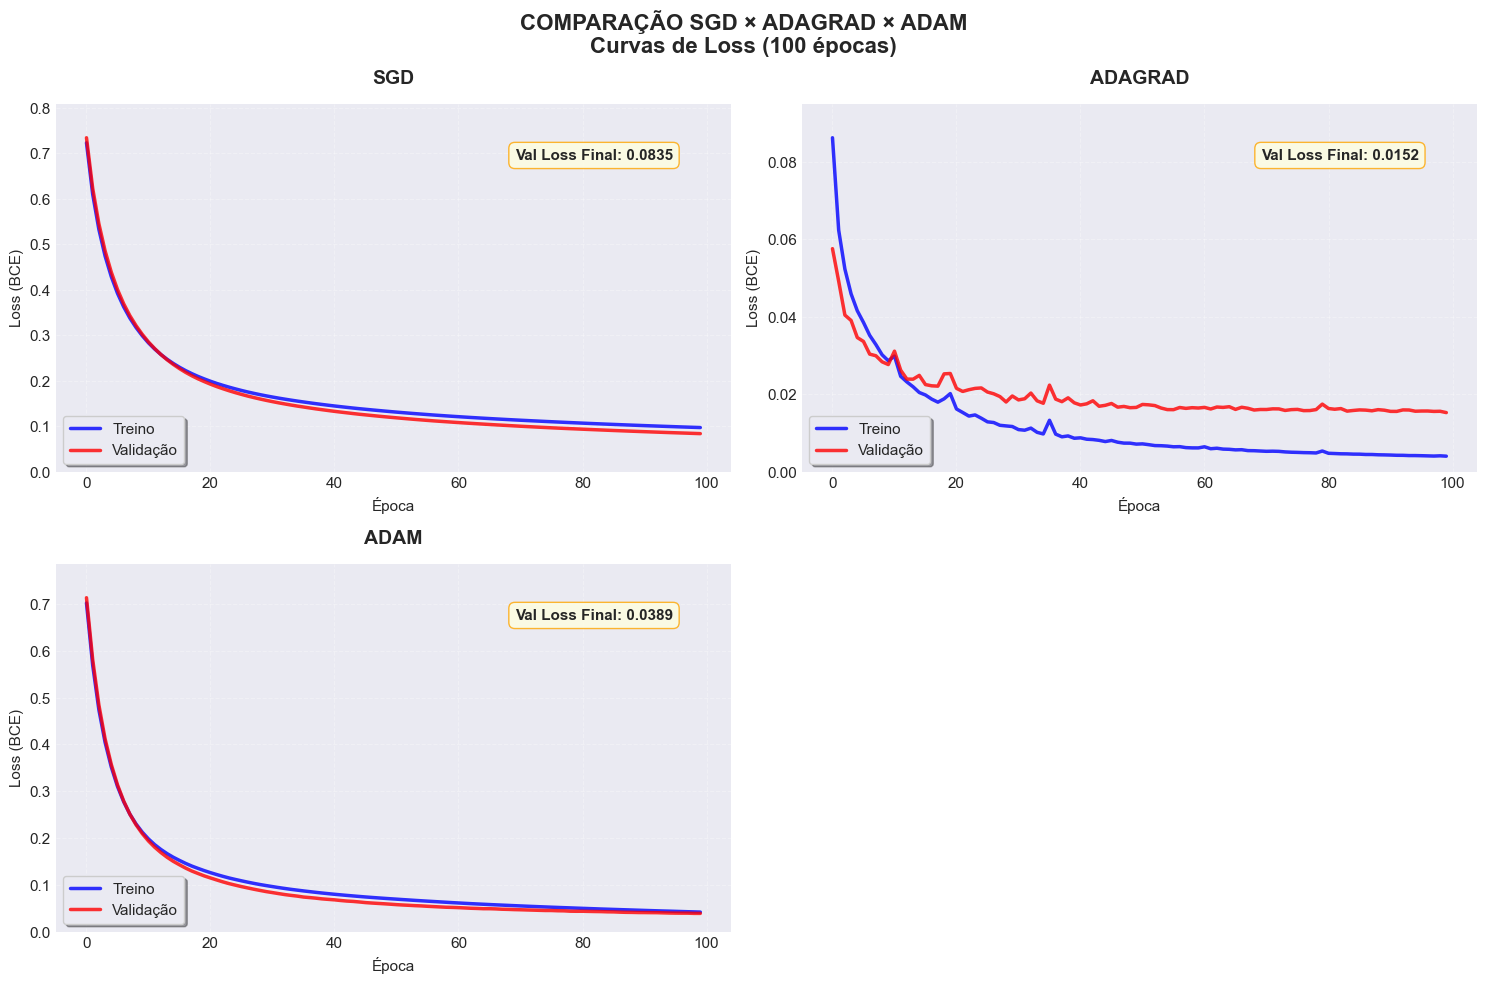

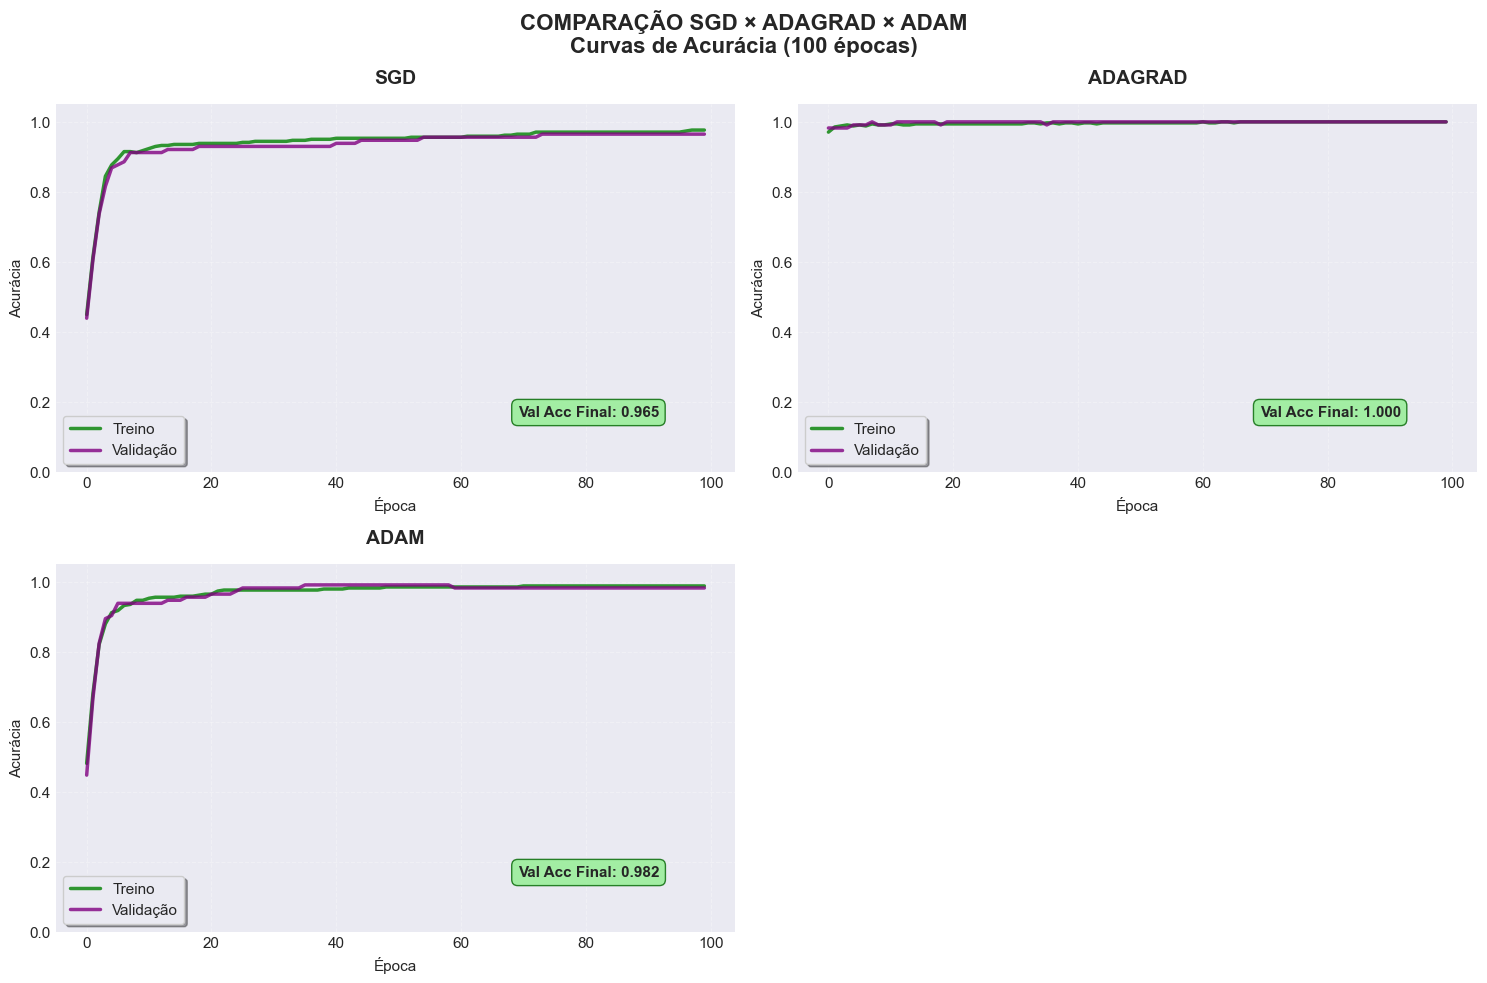


RESUMO FINAL - 3 OTIMIZADORES

Otimizador Val Acc Final Melhor Val Acc Loss Final
       SGD         0.965          0.965     0.0835
   ADAGRAD         1.000          1.000     0.0152
      ADAM         0.982          0.991     0.0389


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for idx, (nome, hist) in enumerate(historico.items()):
    row = idx // 2
    col = idx % 2
    
    ax = axes[row, col]
    
    # Loss
    ax.plot(hist['train_loss'], label='Treino', linewidth=2.5, color='blue', alpha=0.8)
    ax.plot(hist['val_loss'], label='Validação', linewidth=2.5, color='red', alpha=0.8)
    ax.set_title(f'{nome.upper()}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss (BCE)')
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Anotação final
    final_loss = hist['val_loss'][-1]
    ax.text(0.68, 0.85, f'Val Loss Final: {final_loss:.4f}', 
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8,
                     edgecolor='orange', linewidth=1))
    
    # Melhora eixo Y
    ax.set_ylim(0, max(max(hist['train_loss']), max(hist['val_loss']))*1.1)

# Remove subplot vazio
axes[1,1].remove()

plt.suptitle('COMPARAÇÃO SGD × ADAGRAD × ADAM\nCurvas de Loss (100 épocas)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Gráficos de Acurácia 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for idx, (nome, hist) in enumerate(historico.items()):
    row = idx // 2
    col = idx % 2
    
    ax = axes[row, col]
    
    # Acurácia
    ax.plot(hist['train_acc'], label='Treino', linewidth=2.5, color='green', alpha=0.8)
    ax.plot(hist['val_acc'], label='Validação', linewidth=2.5, color='purple', alpha=0.8)
    ax.set_title(f'{nome.upper()}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Época')
    ax.set_ylabel('Acurácia')
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Anotação final
    final_acc = hist['val_acc'][-1]
    ax.text(0.68, 0.15, f'Val Acc Final: {final_acc:.3f}', 
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen', alpha=0.8,
                     edgecolor='darkgreen', linewidth=1))
    
    # Formatação eixo Y (0-1)
    ax.set_ylim(0, 1.05)

# Remove subplot vazio
axes[1,1].remove()

plt.suptitle('COMPARAÇÃO SGD × ADAGRAD × ADAM\nCurvas de Acurácia (100 épocas)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Tabela final comparativa
print()
print("RESUMO FINAL - 3 OTIMIZADORES")
print()
resumo = []
for nome, hist in historico.items():
    resumo.append({
        'Otimizador': nome.upper(),
        'Val Acc Final': f"{hist['val_acc'][-1]:.3f}",
        'Melhor Val Acc': f"{max(hist['val_acc']):.3f}",
        'Loss Final': f"{hist['val_loss'][-1]:.4f}"
    })

df_resumo = pd.DataFrame(resumo)
print(df_resumo.to_string(index=False))

## Análise Comparativa dos Otimizadores

Após treinar a mesma arquitetura de rede neural (30 $\to$ 16 $\to$ 1) por 100 épocas com os três otimizadores, podemos comparar seus comportamentos sob diferentes perspectivas.

### Velocidade de Convergência

O **Adam** foi o mais rápido: já na época 10 apresentava val_loss de ~0.04, e na época 60 já havia atingido val_loss abaixo de 0.01 - um ritmo que o SGD só alcançou perto da época 80. O **AdaGrad** surpreendeu positivamente na velocidade inicial: convergiu ainda mais rápido que o Adam nas primeiras 30 épocas (val_loss de 0.018 na época 30), mas logo desacelerou por conta do seu acumulador de gradientes crescente. O **SGD** foi o mais lento, mas progrediu de forma consistente e linear ao longo de todo o treinamento.

Esse comportamento ilustra bem a teoria: o Adam combina momentum com taxa adaptativa, o que o torna naturalmente mais agressivo nas primeiras épocas.

### Estabilidade do Treinamento

O **SGD** apresentou as curvas de loss mais suaves e monotonicamente decrescentes - característico de um otimizador que avança devagar e sem "memória". O **AdaGrad** também foi estável, mas com o comportamento típico de "plateau": após ~40 épocas, a taxa de aprendizado efetiva de cada parâmetro já tinha caído tanto que os updates ficaram praticamente nulos, e a val_loss parou de cair - ou até subiu levemente. O **Adam** foi o menos estável na curva de validação: houve algumas oscilações pontuais (ex: época 70 e 40), reflexo do ruído introduzido pelos momentos adaptativos, embora a tendência geral fosse fortemente descendente.

### Generalização (Train vs. Validação)

O ponto mais interessante da comparação é o comportamento no conjunto de **teste**, que revela o poder de generalização real:

| Otimizador | Val Acc Final | Test Acc | Gap |
|------------|:---:|:---:|:---:|
| SGD        | 1.000 | 0.956 | −4.4% |
| AdaGrad    | 0.991 | 0.974 | −1.7% |
| Adam       | 1.000 | 0.974 | −2.6% |

O **SGD**, apesar de atingir acurácia perfeita na validação, apresentou o **maior gap** para o teste (4.4%). Isso indica que com taxa de aprendizado fixa e sem adaptatividade, o modelo tende a "decorar" melhor os dados vistos - o que é uma forma sutil de overfitting.

O **AdaGrad** teve o melhor balanço treino/generalização: a taxa efetiva decrescente funcionou como uma forma implícita de regularização, impedindo que o modelo se ajustasse excessivamente. Seu val_acc final foi 0.991, abaixo dos outros dois, mas isso reflete maior honestidade da estimativa de generalização - e o teste confirmou.

O **Adam**, com o menor val_loss final (0.0035), demonstrou que a combinação de momentum + taxa adaptativa permite encontrar mínimos mais "profundos" da função de perda. O gap de 2.6% é intermediário, e a acurácia de teste (0.974) empata com AdaGrad.

### Conclusão da Análise

Nenhum otimizador "ganhou" em todas as dimensões...

- **SGD** é o baseline robusto e interpretável, mas exige ajuste cuidadoso do learning rate e tende a overfittar mais em datasets pequenos;
- **AdaGrad** é ideal quando as features têm escalas muito diferentes (como neste dataset, onde radius_mean e fractal_dimension diferem em ordens de grandeza), e sua regularização implícita pode ajudar na generalização;
- **Adam** converge mais rápido e chega a losses menores, mas exige atenção ao overfitting -especialmente em datasets pequenos como este (~341 amostras de treino).

Para o problema de diagnóstico de câncer de mama especificamente, onde **minimizar falsos negativos** (tumores malignos classificados como benignos) é crítico, a métrica mais relevante seria o **recall da classe maligna** - e não apenas a acurácia geral. Essa análise de recall por classe seria uma extensão natural deste trabalho.

## Conclusão

Este trabalho implementou e comparou três otimizadores fundamentais - SGD, AdaGrad e Adam - em Python puro, aplicados ao problema de diagnóstico de câncer de mama (Breast Cancer Wisconsin dataset).

### O que foi aprendido

A implementação from scratch revelou algo que bibliotecas como PyTorch escondem: os otimizadores diferem não apenas nas fórmulas, mas na **dinâmica de como o modelo aprende**. Ao acumular gradientes manualmente e aplicar uma única atualização por mini-batch, ficou evidente que a granularidade do update tem impacto direto na suavidade das curvas de aprendizado.

Do ponto de vista matemático, os três otimizadores partem da mesma fórmula base $\theta_{t} = \theta_{t-1} - \alpha \nabla L$, mas divergem em **como definem o "passo efetivo"**:

- SGD usa o gradiente bruto com taxa fixa;
- AdaGrad divide o gradiente pela raiz do histórico acumulado — taxas individuais por parâmetro, decrescentes no tempo;
- Adam combina a média móvel do gradiente (direção suavizada) com a média móvel do gradiente quadrático (normalização de escala), com correção de bias nas primeiras épocas.

### Resultados Principais

Todos os três otimizadores alcançaram acurácias elevadas no conjunto de teste (95.6% a 97.4%), demonstrando que a arquitetura escolhida (30 → 16 → 1, ReLU + Sigmoid, BCE) é adequada para o problema. As diferenças entre os otimizadores se manifestaram principalmente em:

1. **Velocidade de convergência**: Adam > AdaGrad (nas primeiras épocas) > SGD;
2. **Estabilidade**: SGD > AdaGrad > Adam;
3. **Generalização**: AdaGrad ≈ Adam > SGD (menor gap val/teste).

### Limitações e Próximos Passos

Este experimento foi realizado com um único conjunto de hiperparâmetros e seed fixo. Para uma comparação mais rigorosa, seria recomendável:

- **Validação cruzada** (k-fold) para reduzir a variância dos resultados;
- **Análise de métricas clínicas** como recall da classe maligna, F1-score e AUC-ROC, mais relevantes para diagnóstico médico do que a acurácia pura;
- **Implementação de SGD com Momentum e RMSProp**, os dois otimizadores mencionados na seção teórica mas não implementados neste trabalho;
- **Variação de hiperparâmetros** (learning rate scheduling, diferentes batch sizes) para analisar a sensibilidade de cada otimizador;
- **Arquiteturas mais profundas** para observar se o comportamento comparativo se mantém com mais camadas e o problema do gradiente desaparecendo.

## Referências

**Dataset**

WOLBERG, W. H.; STREET, W. N.; MANGASARIAN, O. L. *Breast Cancer Wisconsin (Diagnostic) Dataset*. UCI Machine Learning Repository, 1995. Disponível em: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29

---

**Otimizadores**

RUMELHART, D. E.; HINTON, G. E.; WILLIAMS, R. J. Learning representations by back-propagating errors. *Nature*, v. 323, p. 533–536, 1986.

DUCHI, J.; HAZAN, E.; SINGER, Y. Adaptive subgradient methods for online learning and stochastic optimization. *Journal of Machine Learning Research*, v. 12, p. 2121–2159, 2011.

KINGMA, D. P.; BA, J. Adam: A method for stochastic optimization. In: *International Conference on Learning Representations (ICLR)*, 2015. Disponível em: https://arxiv.org/abs/1412.6980

---

**Redes Neurais e Backpropagation**

GOODFELLOW, I.; BENGIO, Y.; COURVILLE, A. *Deep Learning*. Cambridge: MIT Press, 2016. Disponível em: https://www.deeplearningbook.org

HE, K. et al. Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification. In: *IEEE International Conference on Computer Vision (ICCV)*, 2015. (referência para a inicialização He usada no trabalho)

---

**Mini-Batch Gradient Descent**

LECUN, Y. et al. Efficient BackProp. In: MONTAVON, G.; ORR, G. B.; MÜLLER, K.-R. (Ed.). *Neural Networks: Tricks of the Trade*. 2. ed. Berlin: Springer, 2012. p. 9–48.

---
**Geral**
Materiais disponibilizados pelo professor na disciplina.